# **Training and using a new surrogate in fiesta**

This notebook demonstrates how to train a new fiesta surrogate model from scratch, using the kilonova model of Dietrich et al. (2020) (``Bu2019lm``) as an example: preprocessing the raw POSSIS training data into fiesta's training format, training MLP and CVAE surrogates on it, and benchmarking the result.

This needs a working environment with `fiesta` installed.

##### **Checking for an existing surrogate**

Before training a new surrogate from scratch, it's worth checking whether fiesta already ships one for the model we're after. Fiesta has both built-in surrogates (already installed) and downloadable ones (hosted on Hugging Face).

In [24]:
from fiesta.surrogates import print_built_in_surrogates
print_built_in_surrogates()

14:01 fiesta INFO    : Available built-in surrogates in fiesta are:


And which surrogates are available for download:

In [25]:
from fiesta.surrogates import print_downloadable_surrogates
print_downloadable_surrogates()

14:01 fiesta INFO    : Downloadable surrogates for fiesta are:
14:01 fiesta INFO    : 	 ==================== 
14:01 fiesta INFO    : 	 	-KN-
14:01 fiesta INFO    : 	 Bu2026_MLP
14:01 fiesta INFO    : 	 Brethauer2025_MLP
14:01 fiesta INFO    : 	 Bu2026_CVAE
14:01 fiesta INFO    : 	 Bu2025_CVAE
14:01 fiesta INFO    : 	 Bu2025_lc
14:01 fiesta INFO    : 	 Bu2025_MLP
14:01 fiesta INFO    : 	 Brethauer2025_CVAE
14:01 fiesta INFO    : 	 ==================== 
 

14:01 fiesta INFO    : 	 ==================== 
14:01 fiesta INFO    : 	 	-GRB-
14:01 fiesta INFO    : 	 pbag_gaussian_CVAE
14:01 fiesta INFO    : 	 afgpy_gaussian_MLP
14:01 fiesta INFO    : 	 afgpy_tophat_CVAE
14:01 fiesta INFO    : 	 afgpy_tophat_MLP
14:01 fiesta INFO    : 	 pbag_gaussian_MLP
14:01 fiesta INFO    : 	 pbag_tophat_MLP
14:01 fiesta INFO    : 	 pbag_tophat_CVAE
14:01 fiesta INFO    : 	 blastwave_gaussian_CVAE
14:01 fiesta INFO    : 	 afgpy_gaussian_CVAE
14:01 fiesta INFO    : 	 blastwave_rs_gaussian_CVAE
14:01 fiesta INFO

## **Training a Bu2019lm surrogate from scratch**

Now we turn to the case where we want to train a new surrogate.

Specifically, we want to train a surrogate for the kilonova model from Dietrich et al. (2020) (https://arxiv.org/abs/2002.11355), commonly referred to as ``Bu2019lm`` in the literature.

Before training it ourselves, let's check whether fiesta already ships this as a built-in or downloadable surrogate (see the ``print_built_in_surrogates`` and ``print_downloadable_surrogates`` calls above): the downloadable list only contains ``Bu2025_*``, ``Bu2026_*``, and ``Brethauer2025_*`` models — no ``Bu2019lm``. So this is a good candidate to train from scratch as a demo.

The training data (the raw POSSIS spectral simulations, the ``.dat`` lightcurve files) is hosted as a zip file on Google Drive. Below we download that zip file into ``./output`` using ``gdown``.
The original set of files is available [here](https://drive.google.com/drive/folders/1DadJROhaADKVrMPsnXOpmpXerMSH0ShC), the link we point to is just pointing to a single zip file containing all those files, since downloading each file individually might take a long time. 

This requires ``gdown`` (a small utility for downloading files from Google Drive), which is listed as an optional ``dev`` dependency of fiestaEM rather than a core one. If it's not already installed in your environment, install it first with ``pip install -e ".[dev]"`` (or ``uv sync --extra dev`` if you're using uv), then re-run the cell below. (or just ``pip install gdown``). 

We then use it to download the training-data zip file and extract it into ``./output``, next to this notebook. Everything under ``./output`` is git-ignored, so running this notebook won't leave any downloaded or generated files tracked by git.

In [26]:
import os
import zipfile
import gdown

os.makedirs("./output", exist_ok=True)

# https://drive.google.com/file/d/1u8XVxE-lOc8sbOyL5Xfd_QE7La1mtzXD/view?usp=sharing
zip_path = "./output/2020_dietrich_Bu2019lm.zip"
gdown.download(id="1u8XVxE-lOc8sbOyL5Xfd_QE7La1mtzXD", output=zip_path, quiet=False)

with zipfile.ZipFile(zip_path) as zf:
    zf.extractall("./output/Bu2019lm_training_data")

Downloading...
From (original): https://drive.google.com/uc?id=1u8XVxE-lOc8sbOyL5Xfd_QE7La1mtzXD
From (redirected): https://drive.google.com/uc?id=1u8XVxE-lOc8sbOyL5Xfd_QE7La1mtzXD&confirm=t&uuid=50c479ad-8a0c-49b6-b30f-18184293c067
To: /Users/Woute029/Documents/Code/projects/NMMA_2026/tutorials/fiestaEM/docs/user_guide/training/output/2020_dietrich_Bu2019lm.zip
100%|██████████| 258M/258M [00:10<00:00, 24.0MB/s] 


##### **a) Creating a training data file**



In fiesta, training a machine-learning surrogate starts from a ``.h5`` file that contains all the raw training data plus the metadata.

This ``.h5`` file must have a certain layout. Specifically, it has to include the following data sets as metadata:

- ``times`` : An array for the time domain of the data in days.

- ``nus`` : An array for the frequency domain of the data in Hz.

- ``parameter_names`` : A list of strings that contains the parameter names. This determines which parameter names need to be present in the param-dict that is the argument for the surrogate prediction.

- ``parameter_distributions`` : A string-converted dictionary that has ``parameter_names`` as keys and the values are tuples ``tuple[float, float, str]``. The first two numbers are the minimum and maximum 
    range of this parameter in the training data, i.e., the range in which the trained surrogate will be valid. The string should indicate which distribution the training parameter samples follow, though there are no negative side-effects should the distribution provided here be inaccurate.

Further, there should be three data sets ``train``, ``val``, and ``test``. Each of these contains an array ``X`` and an array ``y``.

The ``X`` array is the array with the parameter vectors. The ``y`` array is the array with the flux densities at 10 pc (but zero redshift), in units of log10(mJy).

For fiesta it does not really matter, how this file is created, as long as it adheres to the aforementioned format. 
But of course, there are utility functions to convert the outputs of common codes like POSSIS or SEDONA to the fiesta format.

The raw Dietrich et al. (2020) data is *not* in fiesta's own POSSIS ``.hdf5`` format (the one ``convert_POSSIS_outputs_to_h5`` expects), but in POSSIS's older plain-text ascii format. Each file is named ``nph<N>_mejdyn<value>_mejwind<value>_phi<value>.txt`` and its ``README`` describes the layout:

- line 1: number of viewing angles ``Nobs`` stored in the file
- line 2: number of wavelength bins ``Nwave``
- line 3: number of time bins ``Ntime`` and the time range ``(t_i, t_f)`` in days
- then, for each viewing angle (``Nobs`` blocks stacked one after another): ``Nwave`` rows of ``wavelength [Å], flux(t_0), flux(t_1), ...`` with the flux density given in erg s⁻¹ cm⁻² Å⁻¹ at a fiducial distance of 10 pc.

The viewing angles are equally spaced in ``cos(theta)`` between 0 (edge-on) and 1 (face-on). For the axisymmetric limits ``phi=0`` and ``phi=90`` degrees the light curve does not depend on viewing angle, so POSSIS only stored a single angle (``Nobs=1``) for those files.

So before we can use fiesta's ``DataManager``, we need a small preprocessing step that:
1. parses ``mej_dyn``, ``mej_wind``, and ``phi`` from the file name,
2. reads the ascii block(s) and converts the ``F_lambda`` flux densities to spectral flux densities in mJy with fiesta's own ``Flambda_to_Fnu`` conversion (the same one used internally by ``convert_POSSIS_outputs_to_h5``),
3. replicates the single-angle files across the full ``cos(theta)`` grid so every training sample has the same 4 parameters ``[log10_mej_dyn, log10_mej_wind, phi, cos_theta]``,
4. and finally writes everything into the ``train``/``val``/``test`` layout fiesta expects.

Since this ascii format is specific to this ``Bu2019lm`` demo (fiesta's own converters, ``convert_POSSIS_outputs_to_h5`` and ``convert_SEDONA_outputs_to_h5`` in ``fiesta.train.utils``, already cover the more common formats), we define the small preprocessing helper functions below right here in the notebook, rather than adding them to the fiesta package itself.

In [27]:
import re

import numpy as np
import tqdm
import jax.numpy as jnp

from fiesta.conversions import Flambda_to_Fnu
from fiesta.train.utils import train_test_split, write_training_data


def read_POSSIS_ascii_parameters(filename: str) -> tuple[float, float, float]:
    match = re.search(r"mejdyn([\d.]+)_mejwind([\d.]+)_phi(\d+)", os.path.basename(filename))
    if match is None:
        raise ValueError(f"Could not parse mejdyn/mejwind/phi from filename {filename}.")
    mej_dyn, mej_wind, phi = match.groups()
    return float(mej_dyn), float(mej_wind), float(phi)


def read_POSSIS_ascii_file(filename: str, cos_theta_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Reads a single POSSIS ascii output file, as used for the Dietrich et al. 2020 ``Bu2019lm``
    kilonova grid. The ascii layout is: line 1 is the number of viewing angles ``nobs`` stored in the
    file, line 2 the number of wavelength bins, line 3 the number of time bins with its (tmin, tmax)
    range in days. The remaining lines contain, per viewing angle (stacked one after another), one row
    per wavelength bin: the wavelength in Angstrom followed by the flux density in erg/s/cm^2/Angstrom
    at a fiducial distance of 10 pc for every time bin.

    Some files (the axisymmetric phi=0 and phi=90 deg limits) only contain a single viewing angle
    because the light curve does not depend on the observer angle there; these are replicated across
    ``cos_theta_grid`` so every returned sample has the same parameter dimensionality.

    Args:
        filename (str): Path to the ascii file.
        cos_theta_grid (np.ndarray): Grid of cos(viewing angle) values that multi-angle files are expected to be sampled on (uniform in [0, 1]).

    Returns:
        tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]: ``X`` (shape ``(n_obs, 4)``, columns ``[mej_dyn, mej_wind, phi, cos_theta]``), ``y`` (shape ``(n_obs, n_nus, n_times)``, log10 of the spectral flux density in mJy at 10 pc), ``times`` (days), ``nus`` (Hz).
    """
    mej_dyn, mej_wind, phi = read_POSSIS_ascii_parameters(filename)

    with open(filename, "r") as f:
        nobs = int(f.readline().split()[0])
        nwave = int(f.readline().split()[0])
        ntime, tmin, tmax = f.readline().split()
        ntime, tmin, tmax = int(ntime), float(tmin), float(tmax)
        data = np.loadtxt(f, max_rows=nobs * nwave)

    dt = (tmax - tmin) / ntime
    times = tmin + dt * (np.arange(ntime) + 0.5)  # bin centers, see the grid's README
    data = data.reshape(nobs, nwave, ntime + 1)
    waves = data[0, :, 0]  # Angstrom, shared by every viewing angle block
    flux = np.maximum(data[:, :, 1:], 1e-15)  # erg / s / cm^2 / Angstrom at 10 pc

    y_per_obs, nus = [], None
    for i in range(nobs):
        mJys, nus = Flambda_to_Fnu(jnp.array(flux[i]), jnp.array(waves))
        y_per_obs.append(np.log10(np.array(mJys)))
    y_per_obs = np.stack(y_per_obs)

    if nobs == 1:
        y = np.repeat(y_per_obs, len(cos_theta_grid), axis=0)
    elif nobs == len(cos_theta_grid):
        y = y_per_obs
    else:
        raise ValueError(f"{filename} has {nobs} viewing angles, expected 1 or {len(cos_theta_grid)}.")

    X = np.array([[mej_dyn, mej_wind, phi, ct] for ct in cos_theta_grid])

    return X, y, times, nus


def convert_POSSIS_ascii_outputs_to_h5(
        dirs: str | list[str],
        outfile: str,
        parameter_names: list[str],
        log_arguments: list[int],
        n_inclinations: int = 11,
        clip: float = 6.5144,
    ) -> None:
    """
    Merges a directory (or several directories) full of POSSIS ascii outputs, as used for the
    Dietrich et al. 2020 ``Bu2019lm`` kilonova grid, into a single training data file in the fiesta
    format. See ``read_POSSIS_ascii_file`` for the expected ascii layout and file naming.

    Args:
        dirs (str | list[str]): directory or list of directories with the ascii files to merge.
        outfile (str): Name of the ``.h5`` training data file to create.
        parameter_names (list[str]): Parameter names for ``[mej_dyn, mej_wind, phi, cos_theta]``, in that order.
        log_arguments (list[int]): Indices of parameters that should be converted to log10 for training (typically mej_dyn and mej_wind).
        n_inclinations (int): Number of viewing angle grid points (cos(theta), uniform in [0, 1]) expected in the multi-angle files. Defaults to 11.
        clip (float): Lower floor value for the minimum log10(mJy) at 10 pc. Every flux density below that will be set to that value. Defaults to 6.5144 (appr. 0 abs. mag).
    """
    if isinstance(dirs, str):
        dirs = [dirs]

    files = []
    for dir in dirs:
        files.extend([os.path.join(dir, f) for f in os.listdir(dir) if f.endswith(".txt")])

    cos_theta_grid = np.linspace(0, 1, n_inclinations)

    X, y, times, nus = [], [], None, None
    for file in tqdm.tqdm(files):
        X_file, y_file, times_file, nus_file = read_POSSIS_ascii_file(file, cos_theta_grid)
        if times is None:
            times, nus = times_file, nus_file
        X.append(X_file)
        y.append(y_file)

    X = np.concatenate(X)
    y = np.concatenate(y)

    if X.shape[1] != len(parameter_names):
        raise ValueError(f"parameter_names do not match parameters stored in the ascii files ({X.shape[1]} parameters found).")

    X[:, log_arguments] = np.log10(X[:, log_arguments])
    y = np.maximum(y, clip)

    train_X, val_X, train_y, val_y = train_test_split(X, y, train_size=0.8)
    val_X, test_X, val_y, test_y = train_test_split(val_X, val_y, train_size=0.5)

    parameter_distributions = {p: (np.min(train_X[:, j]).item(), np.max(train_X[:, j]).item(), "uniform") for j, p in enumerate(parameter_names)}

    write_training_data(outfile, train_X, train_y, val_X, val_y, test_X, test_y, times, nus, parameter_names, parameter_distributions)

In [28]:
convert_POSSIS_ascii_outputs_to_h5(
    dirs="./output/Bu2019lm_training_data/2020_dietrich_Bu2019lm",
    outfile="./output/Bu2019lm_training_data.h5",
    parameter_names=["log10_mej_dyn", "log10_mej_wind", "phi", "cos_theta"],
    log_arguments=[0, 1], # mej_dyn and mej_wind are given in linear mass in the file names, convert to log10 for training
)

100%|██████████| 196/196 [00:04<00:00, 40.15it/s]


##### **b) Training surrogates**

Now that we have a training data file, we can continue with our training procedure.

The intended way to interact with the training data file is through the ``DataManager`` class:

In [29]:
from fiesta.train import DataManager


data = DataManager(
    file="./output/Bu2019lm_training_data.h5",
    tmin=0.1,
    tmax=15,
    numin=5e13,
    numax=1e15,
)

data.print_file_info()

14:01 fiesta INFO    : File info for ./output/Bu2019lm_training_data.h5:
14:01 fiesta INFO    :    Time range in file: 0.10 19.90 days
14:01 fiesta INFO    :    Frequency range in file: 3.00e+13 3.00e+16 Hz
14:01 fiesta INFO    :    Parameter distributions: {'log10_mej_dyn': (-3.0, -1.6989700043360187, 'uniform'), 'log10_mej_wind': (-2.0, -0.8860566476931632, 'uniform'), 'phi': (0.0, 90.0, 'uniform'), 'cos_theta': (0.0, 1.0, 'uniform')}
14:01 fiesta INFO    : 
14:01 fiesta INFO    :    Training data: 1724
14:01 fiesta INFO    :    Validation data: 216
14:01 fiesta INFO    :    Test data: 216
14:01 fiesta INFO    :    Special data:
14:01 fiesta INFO    : 


Here, the ``tmin``, ``tmax``, ``numin``, and ``numax`` arguments are there to cut the flux densities to the desired time and frequency range.

We can now use the trainer classes to have a (more or less automatized) training process. Here we have it for the simple MLP architecture:

In [30]:
from fiesta.train import PCATrainer, NeuralnetConfig
import jax


trainer_mlp = PCATrainer(
    model_name="Bu2019lm_MLP",
    outdir="./output/Bu2019lm_MLP",
    plots_dir="./output/Bu2019lm_MLP",
    data_manager=data,
    n_pca=15,
)

config = NeuralnetConfig(
    name="MLP",
    hidden_layer_sizes=[64, 64],
    learning_rate = 8e-3,

    batch_size=128,
    nb_epochs=1_500,

    weight_decay=0.0,
    dropout_rate=0.0,
    use_cosine_schedule=False,
    cosine_alpha=0.01,
    max_grad_norm=0.0,
)


trainer_mlp.fit(
    config=config,
    key=jax.random.key(47892),
    verbose=True
)

trainer_mlp.save()


trainer_mlp.plot_example_lc(["besselli", "bessellux"])


14:01 fiesta INFO    : Using the following data from ./output/Bu2019lm_training_data.h5 for training the surrogate:
14:01 fiesta INFO    :    Time range loaded: 0.10 15.10 days
14:01 fiesta INFO    :    Number of points in the time array: 76
14:01 fiesta INFO    :    Frequency range loaded: 4.99e+13 1.03e+15 Hz
14:01 fiesta INFO    :    Number of points in the frequency array: 287
14:01 fiesta INFO    :    Parameter names: ['log10_mej_dyn', 'log10_mej_wind', 'phi', 'cos_theta']
14:01 fiesta INFO    : 
14:01 fiesta INFO    :    Training data: 1724
14:01 fiesta INFO    :    Validation data: 216
14:01 fiesta INFO    : 
14:01 fiesta INFO    : Preprocessing data by decomposing data into 15 components.
100%|██████████| 1724/1724 [00:00<00:00, 1908.46it/s]
14:01 fiesta INFO    : PCA decomposition accounts for a share 0.9021223187446594 of the total variance in the training data. This value is hopefully close to 1.
14:01 fiesta INFO    : Preprocessing data . . . done
14:01 fiesta INFO    : Tra

The other architecture implemented is the CVAE. However, its training is rather slow so we do not execute it in this notebook: feel free to uncomment and train it yourself.

In [31]:
from fiesta.train import CVAETrainer
import numpy as np

trainer_cvae = CVAETrainer(
    model_name="Bu2019lm_CVAE",
    outdir="./output/Bu2019lm_CVAE",
    data_manager=data,
    image_size=np.array([50, 75]),
)

config = NeuralnetConfig(
    name="CVAE",
    hidden_layer_sizes=[200, 75, 30],
    learning_rate = 3e-3,

    batch_size=256,
    nb_epochs=1_500,
    
    weight_decay=0.0
)

### TODO: quite slow, skip for now, come back to this later to see if we can make it faster
# trainer_cvae.fit(
#     config=config,
#     key=jax.random.key(5781),
# )
# trainer_cvae.save()
# trainer_cvae.plot_example_lc(["besselli", "bessellux"])

14:01 fiesta INFO    : File info for ./output/Bu2019lm_training_data.h5:
14:01 fiesta INFO    :    Time range in file: 0.10 19.90 days
14:01 fiesta INFO    :    Frequency range in file: 3.00e+13 3.00e+16 Hz
14:01 fiesta INFO    :    Parameter distributions: {'log10_mej_dyn': (-3.0, -1.6989700043360187, 'uniform'), 'log10_mej_wind': (-2.0, -0.8860566476931632, 'uniform'), 'phi': (0.0, 90.0, 'uniform'), 'cos_theta': (0.0, 1.0, 'uniform')}
14:01 fiesta INFO    : 
14:01 fiesta INFO    :    Training data: 1724
14:01 fiesta INFO    :    Validation data: 216
14:01 fiesta INFO    :    Test data: 216
14:01 fiesta INFO    :    Special data:
14:01 fiesta INFO    : 


##### **c) Benchmarking a surrogate**

Now, to check whether the training was actually successful, we need to do some benchmarking of our freshly made surrogates.
For this purpose, fiesta has a benchmarker functionality that will use the ``test`` data from the training data file.

In [ ]:
from fiesta.models import FluxSurrogate
from fiesta.train import Benchmarker

bu2019lm_mlp = FluxSurrogate("Bu2019lm_MLP", ["besselli", "ztfg", "bessellux"], directory="./output/Bu2019lm_MLP")
benchmarker_mlp = Benchmarker(
    model=bu2019lm_mlp,
    data_file="./output/Bu2019lm_training_data.h5",
    outdir="./output/Bu2019lm_MLP",
    metric_name="L2",
    output_format="png"
)

Creating the ``Benchmarker`` already computes the errors on the ``test`` split. Each of its plotting methods saves a PNG into ``outdir`` (here ``./output/Bu2019lm_MLP``); we call them one at a time below instead of the aggregate ``benchmark()`` call so each plot can be inspected separately.

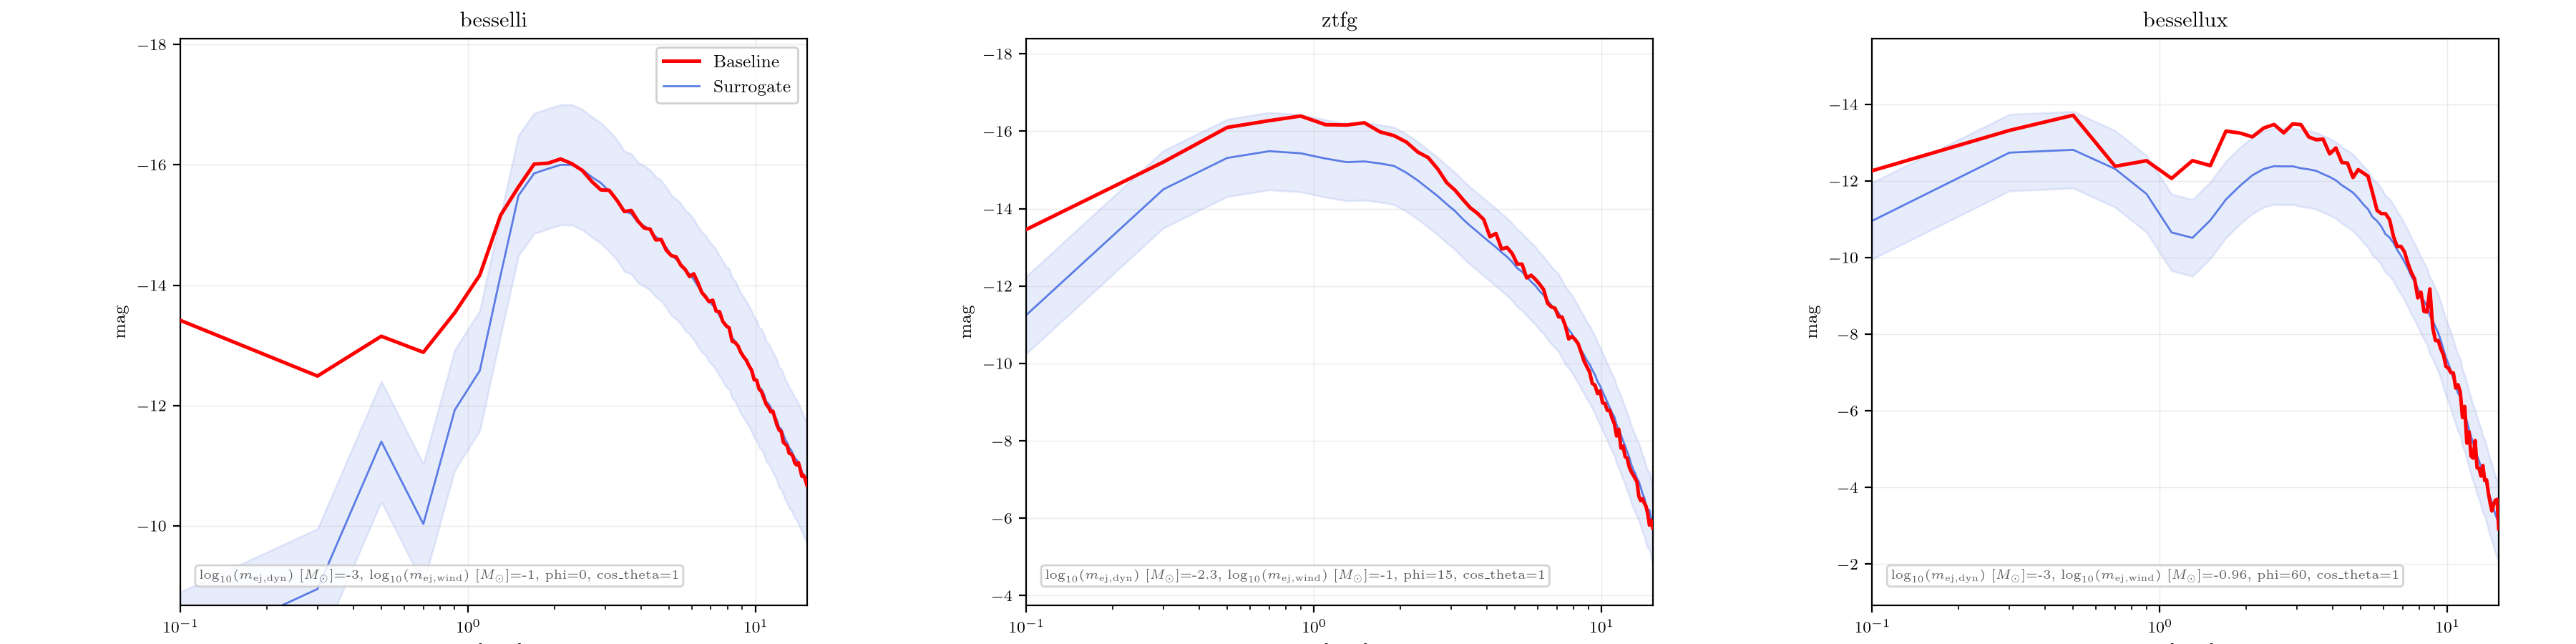

In [33]:
# For each filter, plots the single worst-fit test lightcurve (truth vs. surrogate prediction).
benchmarker_mlp.plot_worst_lightcurves()

from IPython.display import Image
Image(filename="./output/Bu2019lm_MLP/worst_lightcurves_L2.png")

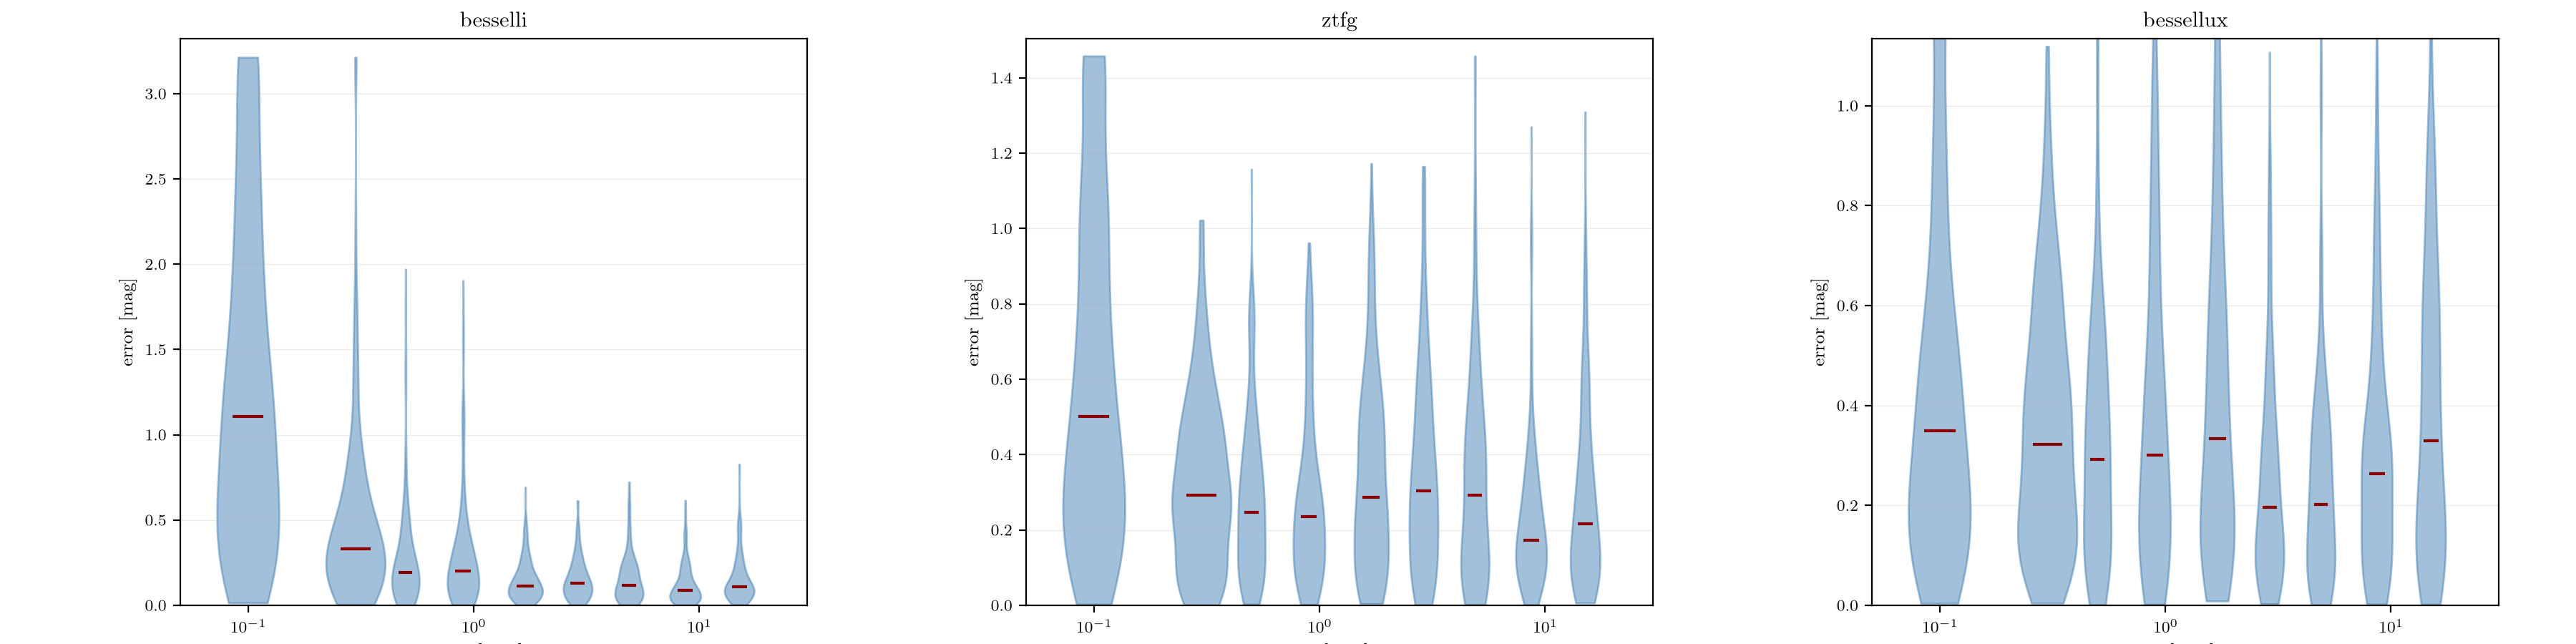

In [34]:
# For each filter, violin plots of the magnitude error at a set of log-spaced times.
benchmarker_mlp.plot_error_over_time()

from IPython.display import Image
Image(filename="./output/Bu2019lm_MLP/error_over_time.png")

/Users/Woute029/Documents/Code/projects/NMMA_2026/tutorials/fiestaEM/src/fiesta/train/Benchmarker.py:22: RuntimeWarning: invalid value encountered in divide
  metric_name: str = "Linf",


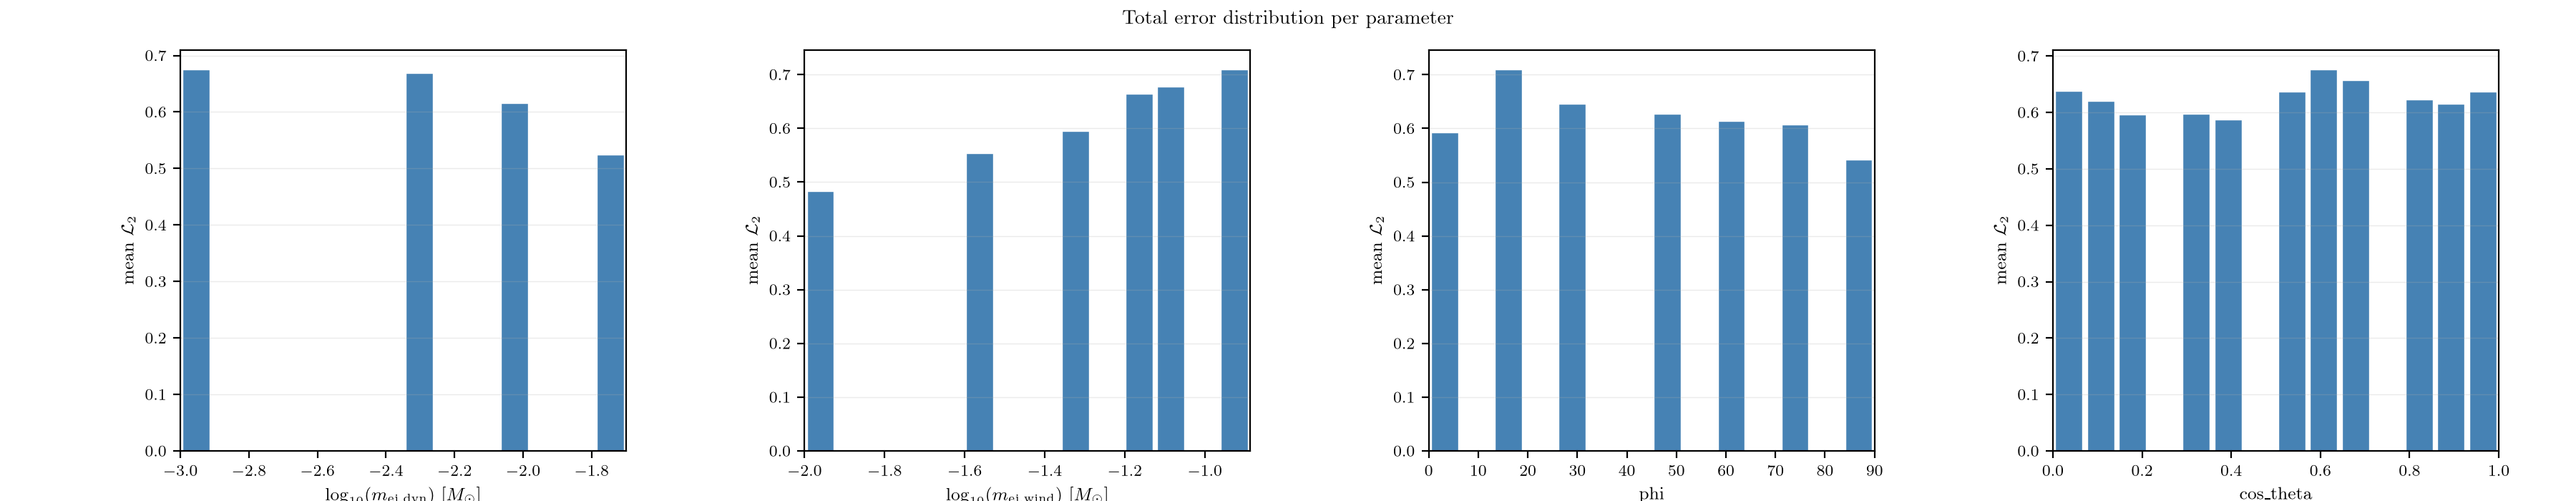

In [35]:
# For each training parameter, the mean total error binned across the parameter's range.
benchmarker_mlp.plot_error_distribution()

from IPython.display import Image
Image(filename="./output/Bu2019lm_MLP/error_distribution.png")

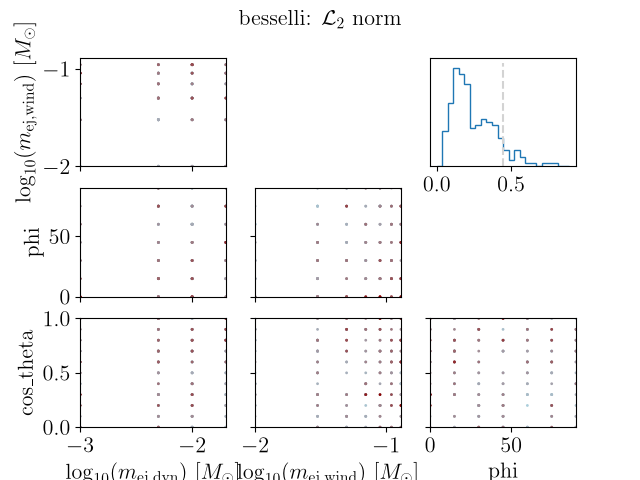

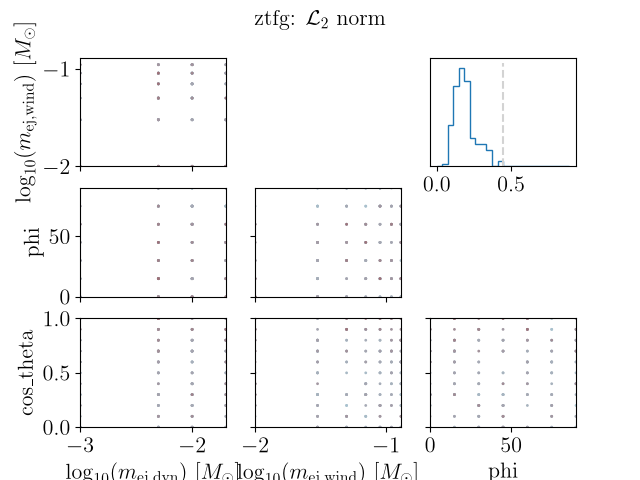

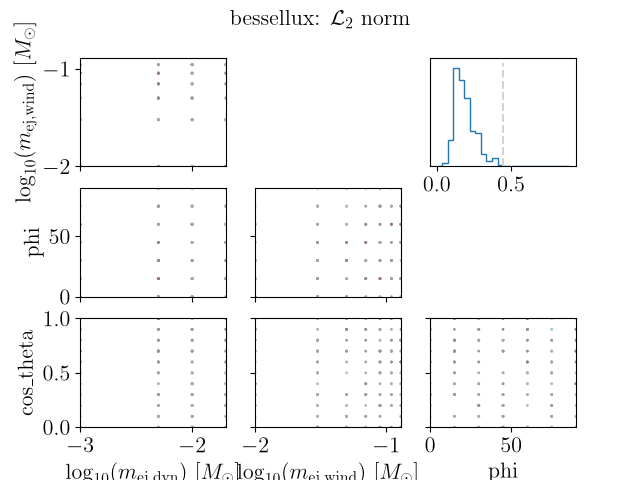

In [36]:
# For each filter, a corner-style scatter of the test points colored by mismatch, plus a histogram of the error metric.
benchmarker_mlp.plot_lightcurves_mismatch()

from IPython.display import Image, display
for filt_name in ["besselli", "ztfg", "bessellux"]:
    display(Image(filename=f"./output/Bu2019lm_MLP/benchmark_{filt_name}_L2.png"))

##### **Exercise**
*Train and benchmark the CVAE model. Which architecture performs better?*